## In This Notebook

This notebook covers the **first half** of the project pipeline — 
getting raw government data into a clean, queryable format.

By the end of this notebook you will have:

1. **Loaded** 500,000 rows from a 2.9GB real CMS Medicare CSV file
2. **Inspected** the data — understanding columns, data types, 
   and missing values
3. **Cleaned** the dataset — dropped unnecessary columns, 
   renamed cryptic CMS codes to human readable names
4. **Saved** everything into a SQLite database ready for SQL queries

This notebook does **not** do any analysis yet — that comes in the 
next notebook `02_sql_analytics.ipynb`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load 500,000 rows from the CMS Medicare dataset
FILE_PATH = 'data/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'
df = pd.read_csv(FILE_PATH,
                nrows = 500000,
                low_memory = False)
#Printing the result to make sure the sampling is successful
print(f"Length Of Rows:{len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst look at the data:")
df.head(3)

Length Of Rows:500,000
Columns: 28

First look at the data:


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,12,12.0,12,250.226667,89.062500,60.312500,54.669167
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,22,22.0,22,318.581818,130.312727,99.380000,98.429545
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with straightforward ...,N,F,76,127.0,127,95.732283,54.820157,43.557323,38.748661


In [3]:
print("Column names and data types:")
print(df.info())
# Upon checking the sampling it seems like there are 6 columns which have null values and the result we found are not important and wont affect our analysis.

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     500000 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     500000 non-null  object 
 2   Rndrng_Prvdr_First_Name        472228 non-null  object 
 3   Rndrng_Prvdr_MI                325704 non-null  object 
 4   Rndrng_Prvdr_Crdntls           443376 non-null  object 
 5   Rndrng_Prvdr_Ent_Cd            500000 non-null  object 
 6   Rndrng_Prvdr_St1               500000 non-null  object 
 7   Rndrng_Prvdr_St2               123181 non-null  object 
 8   Rndrng_Prvdr_City              500000 non-null  object 
 9   Rndrng_Prvdr_State_Abrvtn      500000 non-null  object 
 10  Rndrng_Prvdr_State_FIPS        500000 non-null  object 
 11  Rndrng_Prvdr_Zip5              500000 non-null  int64  
 12  R

In [4]:
missing= df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct
})
print(missing_df[missing_df['missing_count'] > 0])

                         missing_count  missing_percent
Rndrng_Prvdr_First_Name          27772             5.55
Rndrng_Prvdr_MI                 174296            34.86
Rndrng_Prvdr_Crdntls             56624            11.32
Rndrng_Prvdr_St2                376819            75.36
Rndrng_Prvdr_RUCA                  409             0.08
Rndrng_Prvdr_RUCA_Desc             409             0.08


In [5]:
total_missing= df.isnull().sum().sum()
print(f"Total count of missing {total_missing:,}") # Total Missing values 636,329 out of 14,000,000 cells

Total count of missing 636,329


<h1>Cleaning & Renaming the Data</h1>
<b>Dropping columns we don't need</b> — middle initial, address line 2, RUCA codes (rural/urban classifications we won't use in this analysis).
<br><b>Rename columns to human readable names</b>

In [6]:
print(list(df.columns))

['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt']


In [7]:
# Columns we don't need for billing analysis
columns_to_drop = [
    'Rndrng_Prvdr_MI',          # middle initial - not useful
    'Rndrng_Prvdr_St2',         # address line 2 - mostly empty
    'Rndrng_Prvdr_RUCA',        # rural/urban code - not needed
    'Rndrng_Prvdr_RUCA_Desc',   # rural/urban description - not needed
    'Rndrng_Prvdr_State_FIPS',  # FIPS code - we have state abbreviation
    'HCPCS_Drug_Ind',           # drug indicator - out of scope
    'Tot_Bene_Day_Srvcs',       # too granular for our analysis
]

df = df.drop(columns=columns_to_drop)

print(f"Columns before: 28")
print(f"Columns after:  {len(df.columns)}")
print(f"\nRemaining columns:")
print(list(df.columns))

Columns before: 28
Columns after:  21

Remaining columns:
['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt']


In [8]:
# Rename columns to human readable names
df = df.rename(columns={
    'Rndrng_NPI'                  : 'provider_id',
    'Rndrng_Prvdr_Last_Org_Name'  : 'provider_name',
    'Rndrng_Prvdr_First_Name'     : 'first_name',
    'Rndrng_Prvdr_Crdntls'        : 'credentials',
    'Rndrng_Prvdr_Ent_Cd'         : 'entity_type',
    'Rndrng_Prvdr_St1'            : 'address',
    'Rndrng_Prvdr_City'           : 'city',
    'Rndrng_Prvdr_State_Abrvtn'   : 'state',
    'Rndrng_Prvdr_Zip5'           : 'zip_code',
    'Rndrng_Prvdr_Cntry'          : 'country',
    'Rndrng_Prvdr_Type'           : 'specialty',
    'Rndrng_Prvdr_Mdcr_Prtcptg_Ind' : 'medicare_participant',
    'HCPCS_Cd'                    : 'procedure_code',
    'HCPCS_Desc'                  : 'procedure_desc',
    'Place_Of_Srvc'               : 'place_of_service',
    'Tot_Benes'                   : 'total_patients',
    'Tot_Srvcs'                   : 'total_services',
    'Avg_Sbmtd_Chrg'              : 'avg_submitted_charge',
    'Avg_Mdcr_Alowd_Amt'          : 'avg_medicare_allowed',
    'Avg_Mdcr_Pymt_Amt'           : 'avg_medicare_payment',
    'Avg_Mdcr_Stdzd_Amt'          : 'avg_standardized_payment'
})

print("Columns renamed successfully")
print(list(df.columns))

Columns renamed successfully
['provider_id', 'provider_name', 'first_name', 'credentials', 'entity_type', 'address', 'city', 'state', 'zip_code', 'country', 'specialty', 'medicare_participant', 'procedure_code', 'procedure_desc', 'place_of_service', 'total_patients', 'total_services', 'avg_submitted_charge', 'avg_medicare_allowed', 'avg_medicare_payment', 'avg_standardized_payment']


In [9]:
import sqlite3
# Create a connection to SQLite database
# If the file doesn't exist, SQLite creates it automatically
conn = sqlite3.connect('data/cms_medicare.db')
# Save DataFrame to SQLite as a table called 'medicare_billing'
df.to_sql(
    name='medicare_billing',  # table name inside the database
    con=conn,                 # connection we just created
    if_exists='replace',      # if table exists, replace it
    index=False               # don't save the DataFrame index as a column
)

# Always close the connection when done
conn.close()

print("Data saved to SQLite successfully")
print("Database file: data/cms_medicare.db")
print(f"Table: medicare_billing")
print(f"Rows saved: {len(df):,}")

Data saved to SQLite successfully
Database file: data/cms_medicare.db
Table: medicare_billing
Rows saved: 500,000


<h1>Phase 5: Exploratory Data Analysis & Visualizations</h1>

This phase is about turning 500,000 rows of raw Medicare billing numbers into clear, meaningful charts that tell a story anyone can understand.

## Real World Context
Medicare is the US government health insurance program for people over 65 and disabled Americans. In 2023 alone, Medicare paid out over **$800 billion**  to doctors, hospitals and healthcare providers across America.

Not all of that money was spent legitimately.

The FBI estimates Medicare fraud, waste and abuse costs taxpayers an estimated **$60 billion every year**. Detecting it starts exactly here — with understanding what **normal** billing looks like, so we can spot what isn't normal.

## What We're Doing in This Phase
We are building 4 visualizations that answer 4 real business questions:

| # | Business Question | Why It Matters |
|---|---|---|
| 1 | Which specialties bill Medicare the most? | Establishes billing norms by specialty |
| 2 | Which states have the highest Medicare payments? | Identifies geographic billing patterns |
| 3 | How big is the gap between what doctors charge vs what Medicare pays? | Reveals pricing behavior across specialties |
| 4 | Which providers bill suspiciously above their specialty average? | First anomaly detection — finding outliers |

By the end of this phase we will have a clear picture of the Medicare 
billing landscape — and our first list of suspicious providers.

In [10]:
# Visualization settings
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for all charts
plt.rcParams['figure.figsize'] = (12, 6) #runtime configuration paramter : Figure Size set to 12x6
plt.rcParams['font.size'] = 12 #runtime configuration paramter : Font Size set to 12
sns.set_style("whitegrid") #Seaborn style set to white grid
sns.set_palette("husl") # colorblind friendly, vibrant

In [11]:
#Q1.Which specialties bill Medicare the most?
top_specialties=(df.groupby('specialty')['avg_medicare_payment']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

# Rename columns for clarity
top_specialties.columns = ['specialty', 'total_medicare_payment']

# Convert to millions for readability
top_specialties['total_medicare_payment_millions'] = (
    top_specialties['total_medicare_payment'] / 1_000_000
).round(2)

print(top_specialties[['specialty', 'total_medicare_payment_millions']].to_string(index=False))

                 specialty  total_medicare_payment_millions
Ambulatory Surgical Center                             3.68
         Internal Medicine                             2.89
      Diagnostic Radiology                             2.69
        Nurse Practitioner                             2.45
           Family Practice                             2.23
        Orthopedic Surgery                             2.02
                Cardiology                             1.82
             Ophthalmology                             1.59
       Physician Assistant                             1.55
               Dermatology                             1.24


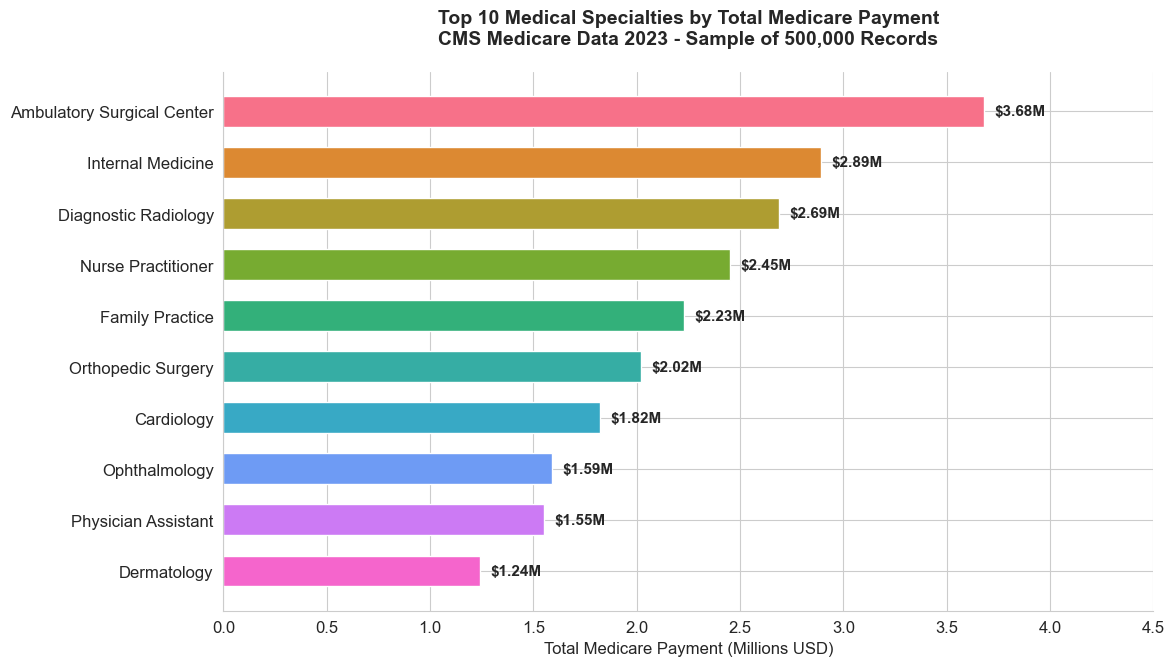

In [12]:
# Chart 1 — Top 10 Specialties by Total Medicare Payment
fig, ax = plt.subplots(figsize=(12, 7))

# Create horizontal bar chart
bars = ax.barh(
    top_specialties['specialty'],
    top_specialties['total_medicare_payment_millions'],
    color=sns.color_palette("husl", 10),
    edgecolor='white',
    height=0.6
)

# Add value labels on each bar
for bar, value in zip(bars, top_specialties['total_medicare_payment_millions']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'${value}M',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Labels and formatting
ax.set_xlabel('Total Medicare Payment (Millions USD)', fontsize=12)
ax.set_title('Top 10 Medical Specialties by Total Medicare Payment\nCMS Medicare Data 2023 - Sample of 500,000 Records',
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.set_xlim(0, 4.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


## Chart 1 - Key Insights

Ambulatory Surgical Centers rank #1 because they are **facilities**, 
not individual doctors - they bill for multiple providers under one entity, 
inflating their total volume.

Primary care specialties like Internal Medicine and Family Practice rank 
high due to **sheer volume of patients** and straightforward procedure 
codes that reimburse quickly with minimal scrutiny.

Cardiology ranks lower than expected despite being one of the most 
expensive specialties because complex cardiac procedures face 
**higher scrutiny and slower reimbursement** from Medicare.

**Key takeaway for anomaly detection:** Comparing all providers together 
is misleading because facilities, high-volume generalists, and specialists 
operate completely differently. A cardiologist billing at the same rate 
as an Ambulatory Surgical Center is not suspicious - it's expected.

> This is why all anomaly detection in this project compares providers 
> **against their own specialty average** - not against the entire dataset.

## Question 2 — Geographic Analysis: Medicare Payments by State

**Business question:** Which US states receive the highest total 
Medicare payments?

**Why it matters:** Geography is a major factor in healthcare billing. 
A provider billing significantly above their state's average is a 
red flag - it suggests either unusually sick patients or potentially 
fraudulent billing. Understanding state-level patterns sets the 
geographic baseline for anomaly detection.

**What to look for in this chart:**
- Which states dominate Medicare spending
- Whether high population states naturally bill more
- Any surprising states that appear in the top 10

In [13]:
# Chart 2 — Top 10 States by Average Medicare Payment
state_payments = (df.groupby('state')['avg_medicare_payment']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

state_payments.columns = ['state', 'avg_payment']
state_payments['avg_payment'] = state_payments['avg_payment'].round(2)

print(state_payments.to_string(index=False))

state  avg_payment
   DC       110.51
   MD       103.96
   NJ        99.37
   FL        98.94
   AZ        96.94
   CA        95.06
   HI        94.71
   MP        91.07
   AK        90.92
   VA        89.87


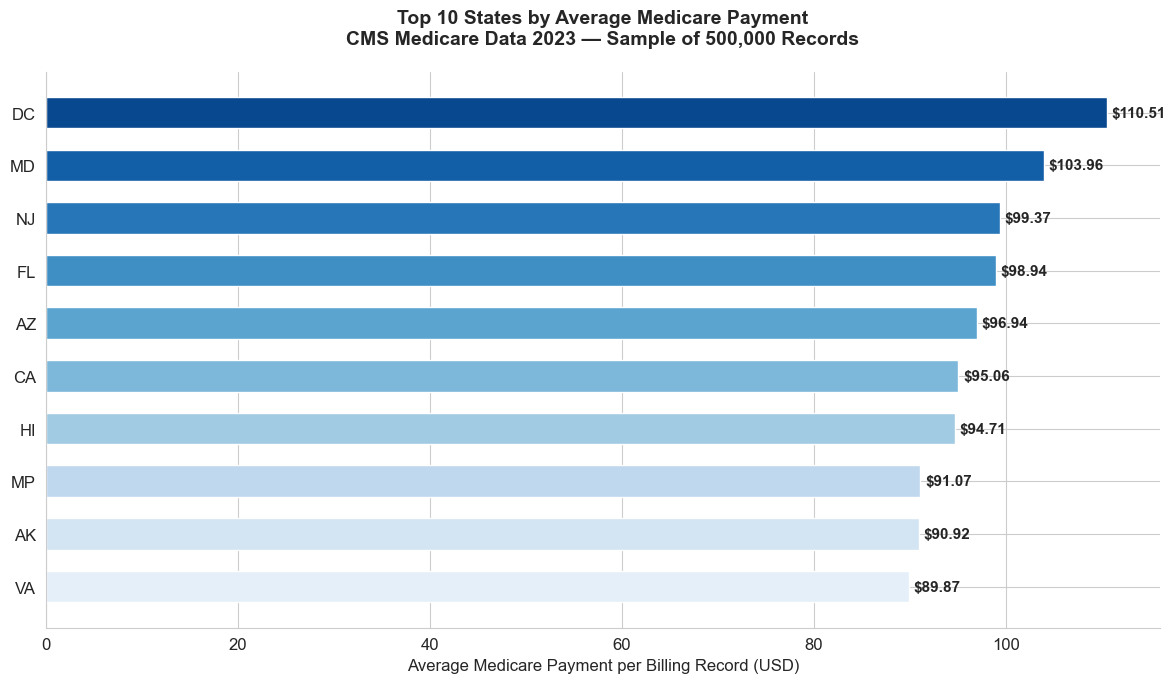

In [14]:
import matplotlib.colors as mcolors
cmap = plt.cm.Blues
colors = [cmap(0.4 + 0.5 * i / len(state_payments)) 
          for i in range(len(state_payments), 0, -1)]

# Chart 2 — Geographic Analysis with gradient colors
fig, ax = plt.subplots(figsize=(12, 7))

# Create gradient colors — darkest for highest, lightest for lowest
colors = sns.color_palette("Blues_r", len(state_payments))

bars = ax.barh(
    state_payments['state'],
    state_payments['avg_payment'],
    color=colors,
    height=0.6,
    edgecolor='white'
)

# Add value labels
for bar, value in zip(bars, state_payments['avg_payment']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'${value}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Labels and formatting
ax.set_xlabel('Average Medicare Payment per Billing Record (USD)', fontsize=12)
ax.set_title('Top 10 States by Average Medicare Payment\nCMS Medicare Data 2023 — Sample of 500,000 Records',
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Chart 2 - Key Insights

**DC ranks #1** not because of Medicare dependency but because of 
procedure complexity - DC has a high concentration of specialists 
performing expensive procedures at major medical centers.

**NJ ranks #3** due to high cost of living, geographic Medicare 
payment adjustments, and proximity to the NYC metro specialist network.

**Key takeaway:** High average payment = high cost area + specialist 
concentration + complex procedures. It does NOT simply mean more 
Medicare dependent population — that drives volume, not average payment.

> **Anomaly detection implication:** Any provider in a lower-cost state 
> billing at DC or NJ level rates warrants immediate investigation.

## Question 3 — The Charge vs Payment Gap
**Business question:** How big is the gap between what doctors charge 
vs what Medicare actually pays — and does it vary by specialty?

**Why it matters:** Doctors routinely inflate submitted charges because 
different insurers pay different percentages of the submitted amount. 
Medicare pays a fixed regulated rate regardless. 

The gap itself is not fraud — it is standard practice. But when a 
provider's gap is dramatically higher than their specialty average, 
it raises a red flag. They may be inflating charges hoping some 
insurer pays the full amount.

**What to look for:**
- Which specialties have the largest charge vs payment gap
- Whether high gap specialties make clinical sense
- Any specialty where the gap seems disproportionately large

In [15]:
# Chart 3 — Charge vs Payment Gap by Specialty
# Calculate average submitted charge and average payment per specialty
gap_analysis = (df.groupby('specialty')
                .agg(
                    avg_charge=('avg_submitted_charge', 'mean'),
                    avg_payment=('avg_medicare_payment', 'mean')
                )
                .round(2)
                .sort_values('avg_charge', ascending=False)
                .head(20)
                .reset_index())

# Calculate the gap
gap_analysis['gap'] = (gap_analysis['avg_charge'] - 
                       gap_analysis['avg_payment']).round(2)

# Calculate gap percentage
gap_analysis['gap_pct'] = (
    (gap_analysis['gap'] / gap_analysis['avg_charge']) * 100
).round(1)

print(gap_analysis[['specialty', 'avg_charge', 
                     'avg_payment', 'gap', 'gap_pct']].to_string(index=False))

                                     specialty  avg_charge  avg_payment     gap  gap_pct
                    Ambulatory Surgical Center     7005.71      1214.89 5790.82     82.7
                      Radiation Therapy Center     2608.45       355.01 2253.44     86.4
                               Cardiac Surgery     2166.81       384.57 1782.24     82.3
                              Thoracic Surgery     1705.22       327.95 1377.27     80.8
                                  Neurosurgery     1606.72       264.61 1342.11     83.5
                    Ambulance Service Provider     1464.22       321.37 1142.85     78.1
                                Anesthesiology     1316.32       100.88 1215.44     92.3
 Certified Registered Nurse Anesthetist (CRNA)     1255.47       103.32 1152.15     91.8
                      Anesthesiology Assistant     1123.11        78.71 1044.40     93.0
                              Vascular Surgery      923.95       216.34  707.61     76.6
Independent Diagnosti

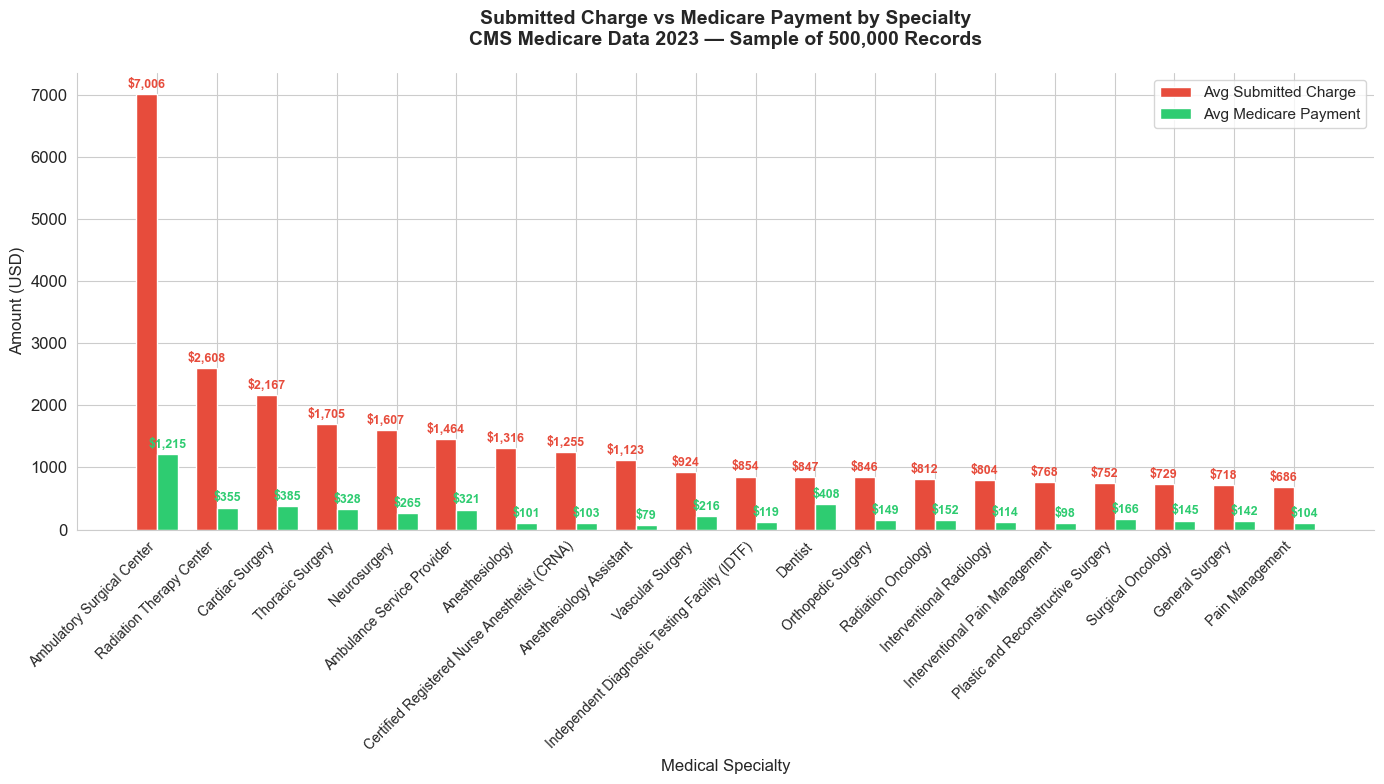

Chart 3 complete


In [16]:
# Chart 3 — Charge vs Payment Gap by Specialty
fig, ax = plt.subplots(figsize=(14, 8))

# Set up bar positions
import numpy as np
x = np.arange(len(gap_analysis))
width = 0.35

# Draw two sets of bars
bars1 = ax.bar(x - width/2, 
               gap_analysis['avg_charge'],
               width, 
               label='Avg Submitted Charge',
               color='#E74C3C',
               edgecolor='white')

bars2 = ax.bar(x + width/2, 
               gap_analysis['avg_payment'],
               width,
               label='Avg Medicare Payment',
               color='#2ECC71',
               edgecolor='white')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'${bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#E74C3C'
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'${bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color='#2ECC71'
    )

# Labels and formatting
ax.set_xlabel('Medical Specialty', fontsize=12)
ax.set_ylabel('Amount (USD)', fontsize=12)
ax.set_title('Submitted Charge vs Medicare Payment by Specialty\nCMS Medicare Data 2023 — Sample of 500,000 Records',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(gap_analysis['specialty'], 
                   rotation=45, 
                   ha='right',
                   fontsize=10)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Chart 3 complete")

## Chart 3 - Key Insights

Medical specialties with high submitted charges share similar gap 
percentages because every provider inflates their chargemaster rates 
to maximize reimbursement from private insurers. Different insurers 
like **Cigna or Aetna** pay a percentage of the submitted charge — 
so a higher submission means a higher payout from them.

**Why the gap itself is not fraud:**
Medicare pays a fixed regulated rate regardless of what the doctor 
submits. Inflating the submitted charge does not affect Medicare 
payment at all-— it only benefits reimbursement from private insurers. 
This is standard industry practice, not fraud.

**What IS actually suspicious:**
A provider whose gap percentage is significantly above their 
specialty average. For example, Anesthesiologists in this dataset 
show a 92-93% gap versus Cardiac Surgery at 82%. However, we cannot 
call this suspicious yet - we first need to know what the average 
anesthesiology gap is across all providers. If 92% is the specialty 
norm, it is completely expected.

> **This is exactly why Chart 4 exists** - anomaly detection compares 
> each provider against their own specialty average, not against the 
> entire dataset. A provider 2-3 standard deviations above their 
> specialty average is where the real red flags appear.

## Question 4 - Anomaly Detection: Who is Billing Suspiciously Above Their Specialty Average?

**Method:** For each specialty we calculate the average and standard 
deviation of submitted charges. Any provider billing more than 
2 standard deviations above their specialty average is flagged 
as a statistical outlier.

**Why 2 standard deviations?** In a normal distribution 95% of 
providers fall within 2 standard deviations. Anyone beyond that 
is in the top 2.5% which is statistically abnormal.

This is the same methodology used by CMS and the FBI for 
Medicare fraud detection.

In [18]:
# Step 1 — Calculate specialty level statistics
specialty_stats = (df.groupby('specialty')['avg_submitted_charge']
                   .agg(['mean', 'std'])
                   .reset_index())

specialty_stats.columns = ['specialty', 'specialty_mean', 'specialty_std']

print(f"Specialties analyzed: {len(specialty_stats)}")
print(specialty_stats.head())

# This gives every provider row their specialty average and std
df_anomaly = df.merge(specialty_stats, on='specialty', how='left')

# Calculating how many standard deviations each provider is from their specialty mean
df_anomaly['z_score'] = (
    (df_anomaly['avg_submitted_charge'] - df_anomaly['specialty_mean']) 
    / df_anomaly['specialty_std']
)

print(f"Total rows: {len(df_anomaly):,}")
print(f"\nZ-score sample:")
print(df_anomaly[['provider_name', 'specialty', 
                   'avg_submitted_charge', 
                   'specialty_mean', 
                   'z_score']].head(10).to_string(index=False))

Specialties analyzed: 101
                                          specialty  specialty_mean  \
0                                Addiction Medicine      245.023795   
1  Advanced Heart Failure and Transplant Cardiology      343.899759   
2                               All Other Suppliers       99.917357   
3                               Allergy/ Immunology      124.496637   
4                        Ambulance Service Provider     1464.223902   

   specialty_std  
0     171.968632  
1     310.797201  
2      60.926087  
3     161.899886  
4    5199.626760  
Total rows: 500,000

Z-score sample:
provider_name   specialty  avg_submitted_charge  specialty_mean   z_score
    Enkeshafi Hospitalist            250.226667      350.048467 -0.385648
    Enkeshafi Hospitalist            318.581818      350.048467 -0.121567
    Enkeshafi Hospitalist             95.732283      350.048467 -0.982517
    Enkeshafi Hospitalist            194.441525      350.048467 -0.601167
    Enkeshafi Hospitalist 

In [19]:
# Step 3 - Flag suspicious providers
# Anyone with z_score above 2 is a statistical outlier
suspicious = (df_anomaly[df_anomaly['z_score'] > 2]
              .groupby(['provider_name', 'specialty'])
              .agg(
                  avg_charge=('avg_submitted_charge', 'mean'),
                  specialty_mean=('specialty_mean', 'mean'),
                  z_score=('z_score', 'mean')
              )
              .reset_index()
              .sort_values('z_score', ascending=False)
              .head(15))

suspicious['z_score'] = suspicious['z_score'].round(2)
suspicious['avg_charge'] = suspicious['avg_charge'].round(2)
suspicious['specialty_mean'] = suspicious['specialty_mean'].round(2)

print(f"Total suspicious providers found: {len(df_anomaly[df_anomaly['z_score'] > 2]):,}")
print(f"\nTop 15 most suspicious providers:")
print(suspicious[['provider_name', 'specialty', 
                   'avg_charge', 'specialty_mean', 
                   'z_score']].to_string(index=False))

Total suspicious providers found: 14,540

Top 15 most suspicious providers:
   provider_name           specialty  avg_charge  specialty_mean  z_score
     Ellenberger  Nurse Practitioner    19993.93          219.99    51.11
         Fleming            Podiatry    13180.00          181.42    45.12
          Taylor        Chiropractic     1190.00           58.86    34.91
       Steinberg  Nurse Practitioner    13581.37          219.99    34.54
Personalis, Inc. Clinical Laboratory     8455.00          103.27    30.52
       Drillings  Orthopedic Surgery    61727.50          845.91    29.57
         Francis Physician Assistant    22819.65          338.54    29.13
           Reber  Nurse Practitioner    11401.92          219.99    28.90
           Olson           Pathology     7299.00          197.01    28.70
          Kawash Physician Assistant    22187.33          338.54    28.31
          Ferrer  Nurse Practitioner    11019.00          219.99    27.91
       Winkleman  Nurse Practitioner

In [20]:
# Step 4 - Investigate the most suspicious providers
# What procedures are these outliers actually billing for?
investigate = ['Ellenberger', 'Drillings', 'Fleming']

suspicious_detail = df_anomaly[
    df_anomaly['provider_name'].isin(investigate)
][['provider_name', 'specialty', 'procedure_code', 
   'procedure_desc', 'avg_submitted_charge', 
   'total_patients', 'z_score'
]].sort_values('avg_submitted_charge', ascending=False)

print(suspicious_detail.to_string(index=False))

provider_name                       specialty procedure_code                                                                                                                       procedure_desc  avg_submitted_charge  total_patients   z_score
    Drillings              Orthopedic Surgery          27447                                                                                        Replacement of knee joint, both sides of knee          70955.000000              22 34.055612
    Drillings              Orthopedic Surgery          27130                                                                              Replacement of thigh bone and hip joint with prosthesis          52500.000000              12 25.091064
  Ellenberger              Nurse Practitioner          22633                                                            Fusion of spine in lower back with partial removal of spine bone and disc          28056.083333              12 71.949256
      Fleming                   

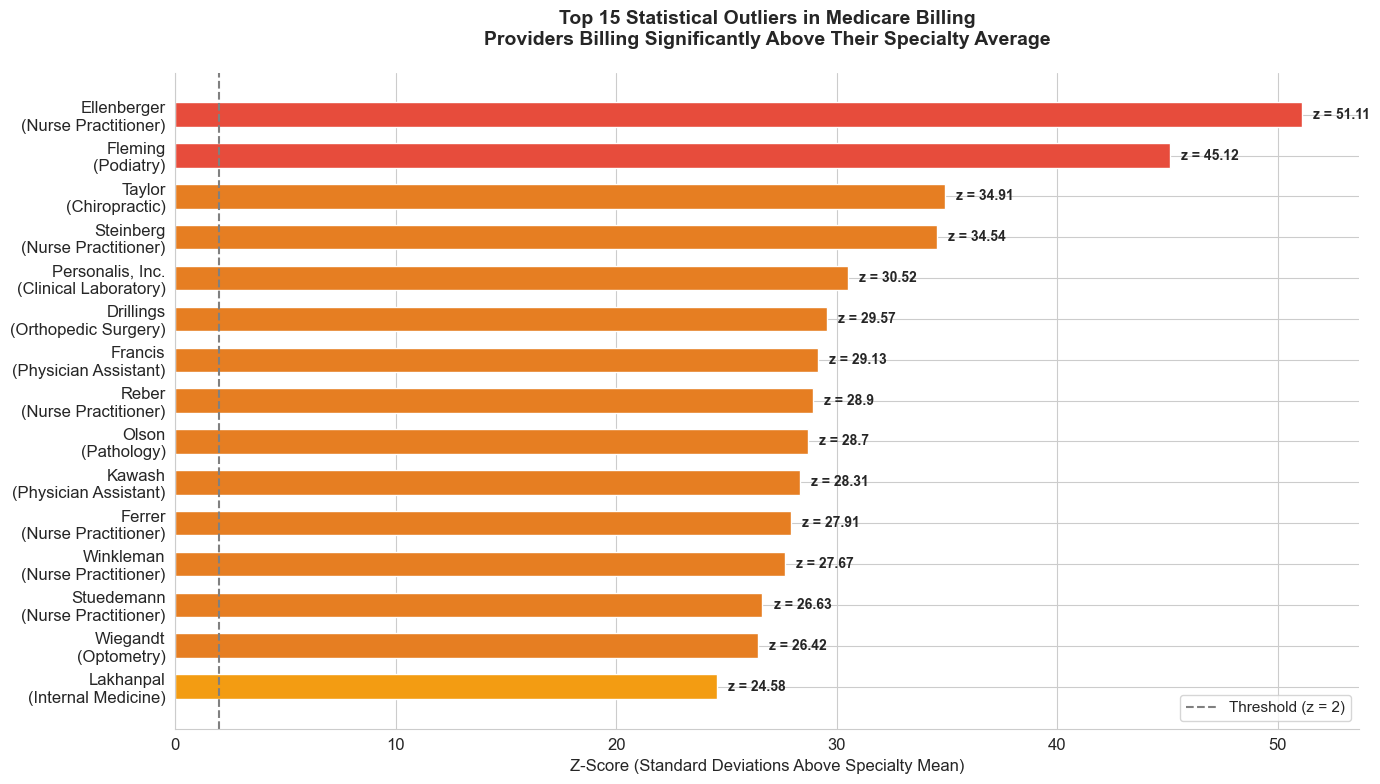

In [22]:
# Chart 4 - Top 15 Suspicious Providers by Z-Score
fig, ax = plt.subplots(figsize=(14, 8))

# Color bars by suspicion level
colors = []
for z in suspicious['z_score']:
    if z > 40:
        colors.append('#E74C3C')   # red - extremely suspicious
    elif z > 25:
        colors.append('#E67E22')   # orange - highly suspicious
    else:
        colors.append('#F39C12')   # yellow - suspicious

bars = ax.barh(
    suspicious['provider_name'] + '\n(' + suspicious['specialty'] + ')',
    suspicious['z_score'],
    color=colors,
    height=0.6,
    edgecolor='white'
)

# Add z-score labels
for bar, value in zip(bars, suspicious['z_score']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'z = {value}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Add vertical line at z=2 showing the threshold
ax.axvline(x=2, color='gray', linestyle='--', 
           linewidth=1.5, label='Threshold (z = 2)')

ax.set_xlabel('Z-Score (Standard Deviations Above Specialty Mean)', fontsize=12)
ax.set_title('Top 15 Statistical Outliers in Medicare Billing\nProviders Billing Significantly Above Their Specialty Average',
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Looking at the Chart 4 findings, Ellenberger who is listed as a 
Nurse Practitioner is billing for spinal fusion surgery. NPs cannot 
perform spinal surgery as it is outside their legal scope of practice. 
This case needs further investigation.

Drillings on the other hand appears to be a legitimate case. The 
procedures listed include knee and hip joint replacements which are 
major orthopedic surgeries and naturally expensive. The high charges 
are expected given the complexity of these procedures.

Fleming is the most complex case. This provider is billing across 
8 different specialties including Internal Medicine, Podiatry, 
Optometry, Family Practice, Orthopedic Surgery, Nurse Practitioner, 
Clinical Psychology and Physician Assistant. Billing across that many 
specialties under one provider name is unusual and is a recognized 
pattern in Medicare fraud investigations. There may be legitimate 
explanations such as a large group practice but it warrants a closer look.

A high z-score flags a provider for review. It does not confirm fraud. 
The real investigation starts here.